# Test Performance Analysis
In this notebook, we analyze the performance of the selected models on the test dataset and account for trading costs on rebalancing.

### Setup

In [1]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import pandas as pd

from scipy import stats
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly.graph_objects as go
from src.utils.io import load_path_config, load_json
from src.data_processing.loading import load_single_csv
from src.utils.constants import EQ_WT_NAME, SP500_NAME
from src.utils.formatting import deserialize_np_dict
from src.evaluation.evaluator import Evaluator
from src.evaluation.selection import pareto_dominance, high_corr_with_each_metric
from src.visualization.plots import plot_3d_pareto, plot_corr, plot_2d_pareto, plot_2d_pareto_diff_colrs

from src.evaluation.metrics import MetricLibrary
from src.models.registry import NNModelLibrary, TradModelLibrary

In [2]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

TradModelLibrary.autodiscover('src.models')
# Registering all NN models to the library
NNModelLibrary.autodiscover('src.models') # MUST be executed for model registration

#### Average Portfolio Performances
This is the average of portfolio metrics over all windows of walk steps. It is not the performances of the models over the entire test period of 2 years.

In [4]:
NUM_SEEDS = 30

test_avg_perf = load_single_csv(
    artifacts_paths['test_perf_dir'] / f'avg_test_perf_all_{NUM_SEEDS}_seeds.csv',
    index_dt=False
)

# Daily returns for all models at all steps
test_returns = load_json(artifacts_paths['test_perf_dir'] / 'test_returns_all.json')

test_avg_perf

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-custom_loss_13,-0.009881,-0.005070,0.001420,-0.099975,-0.025281,1.003301,0.003134
DeformTime-custom_loss_11,0.015962,0.017333,0.055129,-0.177013,-0.052077,1.096021,0.009302
Equal_Weight,-0.011262,-0.009038,-0.001388,-0.095187,-0.022625,0.993425,0.002025
GlobalMinimumVariance,-0.010738,-0.024800,-0.028788,-0.084675,-0.019662,0.958025,-0.000988
HierarchialRiskParity,-0.008913,-0.010000,-0.004387,-0.087700,-0.020313,0.991587,0.001150
MeanVariancePortfolio,-0.047062,-0.043537,-0.071163,-0.156463,-0.034100,0.919462,-0.002475
NaiveMVP,-0.010738,-0.024775,-0.028800,-0.084675,-0.019662,0.958037,-0.000988
NestedClusteredOptimization,-0.000188,-0.004712,-0.011388,-0.081687,-0.020000,1.002263,0.000025
PatchTST-custom_loss_10,-0.004794,-0.000519,0.024426,-0.170336,-0.049618,1.046885,0.006703
PatchTST-custom_loss_11,0.007972,0.006027,0.020643,-0.104126,-0.028687,1.036329,0.005800


### Overall Performance Analysis
Analysis of model average performances on the test set across multiple seeds.

<Axes: title={'center': 'Mean Sharpe (Over All Seeds) vs Portfolio Optimizer'}>

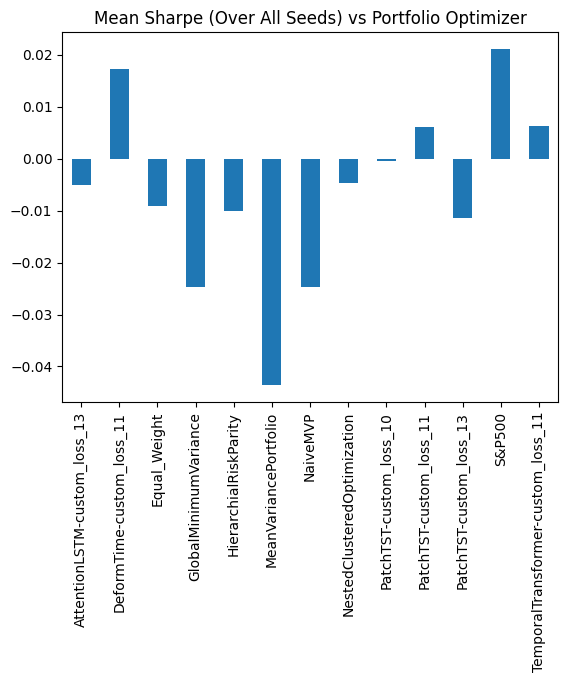

In [5]:
test_avg_perf['sharpe'].plot.bar(title='Mean Sharpe (Over All Seeds) vs Portfolio Optimizer')

<Axes: title={'center': 'Mean CVaR (Over All Seeds) vs Portfolio Optimizer'}>

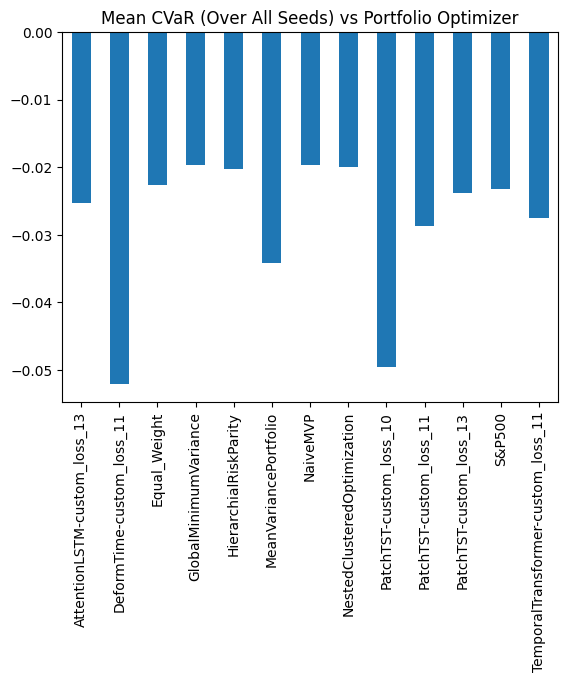

In [6]:
test_avg_perf['cvar'].plot.bar(title='Mean CVaR (Over All Seeds) vs Portfolio Optimizer')

<Axes: title={'center': 'Mean Compounded Returns (Over All Seeds) vs Portfolio Optimizer'}>

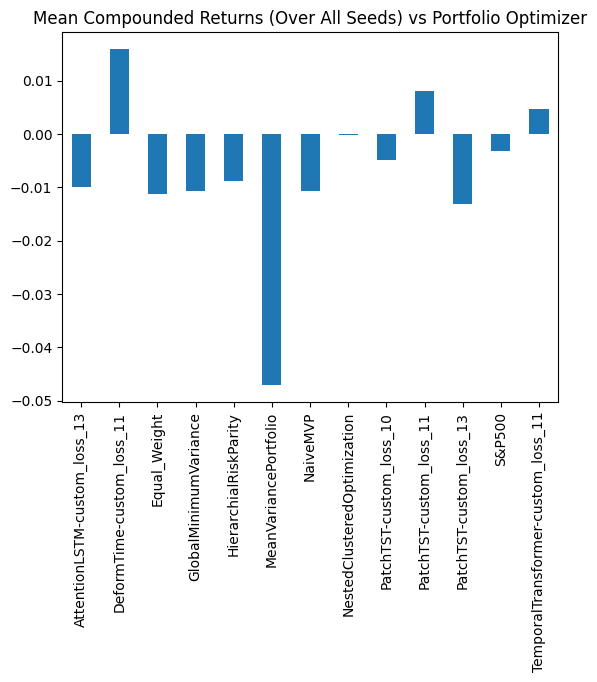

In [7]:
test_avg_perf['compunded_return'].plot.bar(title='Mean Compounded Returns (Over All Seeds) vs Portfolio Optimizer')

#### Models Portfolio Performances
This is the performance of each portfolio for the entire test period (2022-2023)

#### Calculating Multi-Seed Statistics

In [8]:
# Deserialize dict: replace lists with np.array()
test_returns_deserial = deserialize_np_dict(test_returns)

# Separate NN and benchmarks
all_benches = TradModelLibrary.list_models()
all_benches.extend([EQ_WT_NAME, SP500_NAME])

nn_seed_rets = test_returns_deserial['nn_models']
bench_rets = test_returns_deserial['benchmarks']

In [11]:
def update_modl_loss_names(modl_loss_name: str) -> str:
    parts = modl_loss_name.split('-', 1)
    if len(parts) != 2:
        raise ValueError(f'Model + Loss combo name string is incorrect: {modl_loss_name}')
    
    if parts[0] == 'VLSTM':
        updated_modl_name = 'VSN_LSTM'
    else:
        updated_modl_name = parts[0]
    
    if parts[1] == 'custom_loss_10':
        updated_loss_name = 'CustomLossA'
    elif parts[1] == 'custom_loss_11':
        updated_loss_name = 'CustomLossB'
    elif parts[1] == 'custom_loss_13':
        updated_loss_name = 'CustomLossC'
    elif parts[1] == 'custom_loss_14':
        updated_loss_name = 'CustomLossD'
    
    return f'{updated_modl_name}-{updated_loss_name}'

In [12]:
# Remove date range keys for nn returns, We also collect model+loss names
nn_models = []
nn_seed_rets_no_dates = {seed: {} for seed in nn_seed_rets.keys()}
for seed, seed_perfs in nn_seed_rets.items():
    for modl_name, windows_dict in seed_perfs.items():
        updated_name = update_modl_loss_names(modl_name)
        nn_models.append(updated_name)
        nn_seed_rets_no_dates[seed][updated_name] = np.stack(
            [wind_rets for dates, wind_rets in windows_dict.items()]
        )

nn_models = list(set(nn_models))

# Remove date range keys for benchmarks
bench_rets_no_dates = {name: {} for name in bench_rets.keys()}
for modl_name, windows_dict in bench_rets.items():
        bench_rets_no_dates[modl_name] = np.stack(
            [wind_rets for dates, wind_rets in windows_dict.items()]
        )

In [13]:
# Aggregate all performances across seeds
seed_metric_dfs = []
for seed, seed_perfs in nn_seed_rets_no_dates.items():
    evaluator = Evaluator(
        eval_returns=None,
        ba_eval=None,
        all_daily_returns=seed_perfs,
        metrics_lib=MetricLibrary.items()
    )
    seed_metric_dfs.append(evaluator.calc_pf_performances())

all_seed_perf = pd.concat(seed_metric_dfs)

In [14]:
# Calculate performance of benchmark portfolios (no seeds)
evaluator = Evaluator(
    eval_returns=None,
    ba_eval=None,
    all_daily_returns=bench_rets_no_dates, # Deserialize dict: replace lists with np.array()
    metrics_lib=MetricLibrary.items()
)

bench_perfs = evaluator.calc_pf_performances()
bench_perfs = bench_perfs.sort_values(by='sharpe', ascending=False)
bench_perfs

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
NestedClusteredOptimization,-0.0064,0.0034,0.0052,-0.1720,-0.0215,1.0089,0.0002
S&P500,-0.0452,-0.0015,-0.0023,-0.2543,-0.0284,0.9960,-0.0001
HierarchialRiskParity,-0.0794,-0.0112,-0.0178,-0.1980,-0.0224,0.9714,-0.0006
Equal_Weight,-0.0999,-0.0126,-0.0202,-0.2123,-0.0255,0.9678,-0.0007
NaiveMVP,-0.0902,-0.0162,-0.0247,-0.1684,-0.0210,0.9587,-0.0009
GlobalMinimumVariance,-0.0902,-0.0162,-0.0247,-0.1684,-0.0210,0.9587,-0.0009
MeanVariancePortfolio,-0.3425,-0.0437,-0.0692,-0.4363,-0.0363,0.8899,-0.0017


Calculate Statistics for all models over all seeds.

In [15]:
# # Calculate Statistics for Neural networks (across all seeds)
n_seeds= all_seed_perf.groupby(level=0).count().iloc[0, 0] # Extract the common n (assuming all models have same count)
avg_perf_metrics = all_seed_perf.groupby(level=0).mean() # Average over seeds
std_perf_metrics = all_seed_perf.groupby(level=0).std(ddof=1) # Std across seeds
median_perf_metrics = all_seed_perf.groupby(level=0).median()

# Critical t-value for one‑sided 95% confidence
t_val = stats.t.ppf(0.95, df=n_seeds-1)

lower_bound_df = avg_perf_metrics - t_val * (std_perf_metrics / np.sqrt(n_seeds))

Adding benchmarks and tradional models to the above average and lower bound dataframes. We do not need to calculate lower bound for the benchmarks/tradional models because they were not run for multiple seeds. Hence, consider the mean metrics over all windows as their overall performance.


In [16]:
print('AVERAGE PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:')
pd.concat(
    [avg_perf_metrics, bench_perfs],
    axis=0
).sort_values(by='sharpe', ascending=False)

AVERAGE PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
DeformTime-CustomLossB,0.092173,0.014520,0.023977,-0.432250,-0.058140,1.045013,0.001373
PatchTST-CustomLossB,0.050263,0.013793,0.021483,-0.229500,-0.029927,1.037993,0.000943
TemporalTransformer-CustomLossB,0.025313,0.010200,0.016193,-0.229070,-0.029357,1.028257,0.000743
NestedClusteredOptimization,-0.006400,0.003400,0.005200,-0.172000,-0.021500,1.008900,0.000200
PatchTST-CustomLossA,-0.083763,-0.000530,0.000903,-0.424457,-0.053080,1.001850,0.000287
S&P500,-0.045200,-0.001500,-0.002300,-0.254300,-0.028400,0.996000,-0.000100
AttentionLSTM-CustomLossC,-0.091733,-0.008777,-0.014073,-0.226870,-0.028223,0.977450,-0.000490
HierarchialRiskParity,-0.079400,-0.011200,-0.017800,-0.198000,-0.022400,0.971400,-0.000600
Equal_Weight,-0.099900,-0.012600,-0.020200,-0.212300,-0.025500,0.967800,-0.000700
PatchTST-CustomLossC,-0.114200,-0.014230,-0.022850,-0.232980,-0.026660,0.963837,-0.000747


In [18]:
print('MEDIAN PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:')
median_perf_metrics

MEDIAN PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-CustomLossC,-0.09165,-0.00895,-0.01445,-0.22560,-0.02810,0.97690,-0.00050
DeformTime-CustomLossB,0.03915,0.01610,0.02335,-0.40500,-0.05775,1.04480,0.00115
PatchTST-CustomLossA,-0.13875,-0.00205,-0.00270,-0.42465,-0.05340,0.99435,-0.00010
PatchTST-CustomLossB,0.05960,0.01565,0.02500,-0.22950,-0.03010,1.04215,0.00095
PatchTST-CustomLossC,-0.11520,-0.01440,-0.02330,-0.23235,-0.02660,0.96325,-0.00080
TemporalTransformer-CustomLossB,0.01505,0.00920,0.01410,-0.22390,-0.02985,1.02485,0.00055


In [19]:
print('STANDARD DEVIATION OF PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:')
std_perf_metrics

STANDARD DEVIATION OF PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-CustomLossC,0.032925,0.005764,0.009289,0.015397,0.000883,0.014760,0.000327
DeformTime-CustomLossB,0.423346,0.031127,0.049067,0.109163,0.005624,0.089435,0.002231
PatchTST-CustomLossA,0.316498,0.029297,0.043880,0.105808,0.005531,0.083865,0.001778
PatchTST-CustomLossB,0.104698,0.014981,0.023314,0.033335,0.001563,0.041075,0.001021
PatchTST-CustomLossC,0.014171,0.002568,0.004104,0.007918,0.000356,0.006411,0.000133
TemporalTransformer-CustomLossB,0.093932,0.013738,0.021933,0.048176,0.001714,0.038142,0.001028


In [20]:
print('LOWER CONFIDENCE BOUND (95%) PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:')
lower_bound_df = pd.concat(
    [lower_bound_df, bench_perfs],
    axis=0
).sort_values(by='sharpe', ascending=False)
lower_bound_df

LOWER CONFIDENCE BOUND (95%) PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
PatchTST-CustomLossB,0.017784,0.009146,0.014251,-0.239841,-0.030412,1.025251,0.000627
TemporalTransformer-CustomLossB,-0.003826,0.005938,0.009389,-0.244015,-0.029888,1.016424,0.000424
DeformTime-CustomLossB,-0.039156,0.004864,0.008755,-0.466114,-0.059885,1.017269,0.000681
NestedClusteredOptimization,-0.006400,0.003400,0.005200,-0.172000,-0.021500,1.008900,0.000200
S&P500,-0.045200,-0.001500,-0.002300,-0.254300,-0.028400,0.996000,-0.000100
PatchTST-CustomLossA,-0.181946,-0.009618,-0.012709,-0.457280,-0.054796,0.975834,-0.000265
AttentionLSTM-CustomLossC,-0.101947,-0.010565,-0.016955,-0.231646,-0.028497,0.972871,-0.000592
HierarchialRiskParity,-0.079400,-0.011200,-0.017800,-0.198000,-0.022400,0.971400,-0.000600
Equal_Weight,-0.099900,-0.012600,-0.020200,-0.212300,-0.025500,0.967800,-0.000700
PatchTST-CustomLossC,-0.118596,-0.015027,-0.024123,-0.235436,-0.026770,0.961848,-0.000788


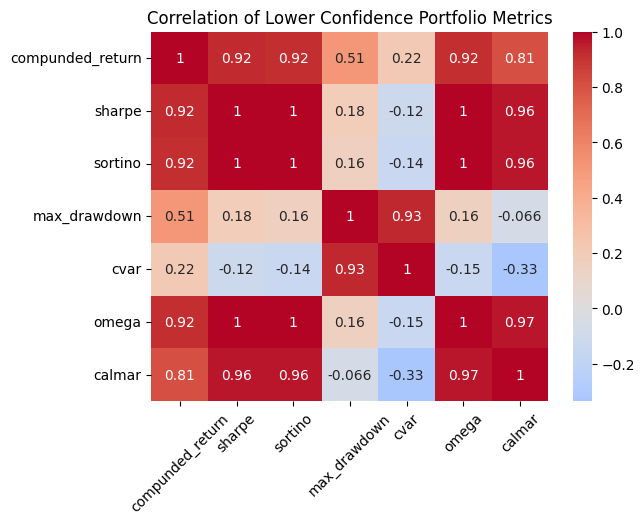


compunded_return is highly correlated with:
  sharpe: 0.924
  sortino: 0.917
  omega: 0.917
  calmar: 0.809

sharpe is highly correlated with:
  compunded_return: 0.924
  sortino: 0.999
  omega: 0.999
  calmar: 0.960

sortino is highly correlated with:
  compunded_return: 0.917
  sharpe: 0.999
  omega: 0.999
  calmar: 0.962

max_drawdown is highly correlated with:
  cvar: 0.931

cvar is highly correlated with:
  max_drawdown: 0.931

omega is highly correlated with:
  compunded_return: 0.917
  sharpe: 0.999
  sortino: 0.999
  calmar: 0.969

calmar is highly correlated with:
  compunded_return: 0.809
  sharpe: 0.960
  sortino: 0.962
  omega: 0.969


In [21]:
corr = lower_bound_df.corr()

plot_corr(corr, title='Correlation of Lower Confidence Portfolio Metrics')
high_corr_with_each_metric(corr, threshold=0.75)

In [22]:
metrics_to_use = ['sharpe', 'cvar']

In [23]:
from src.visualization.plots import plot_box_models_and_benchs

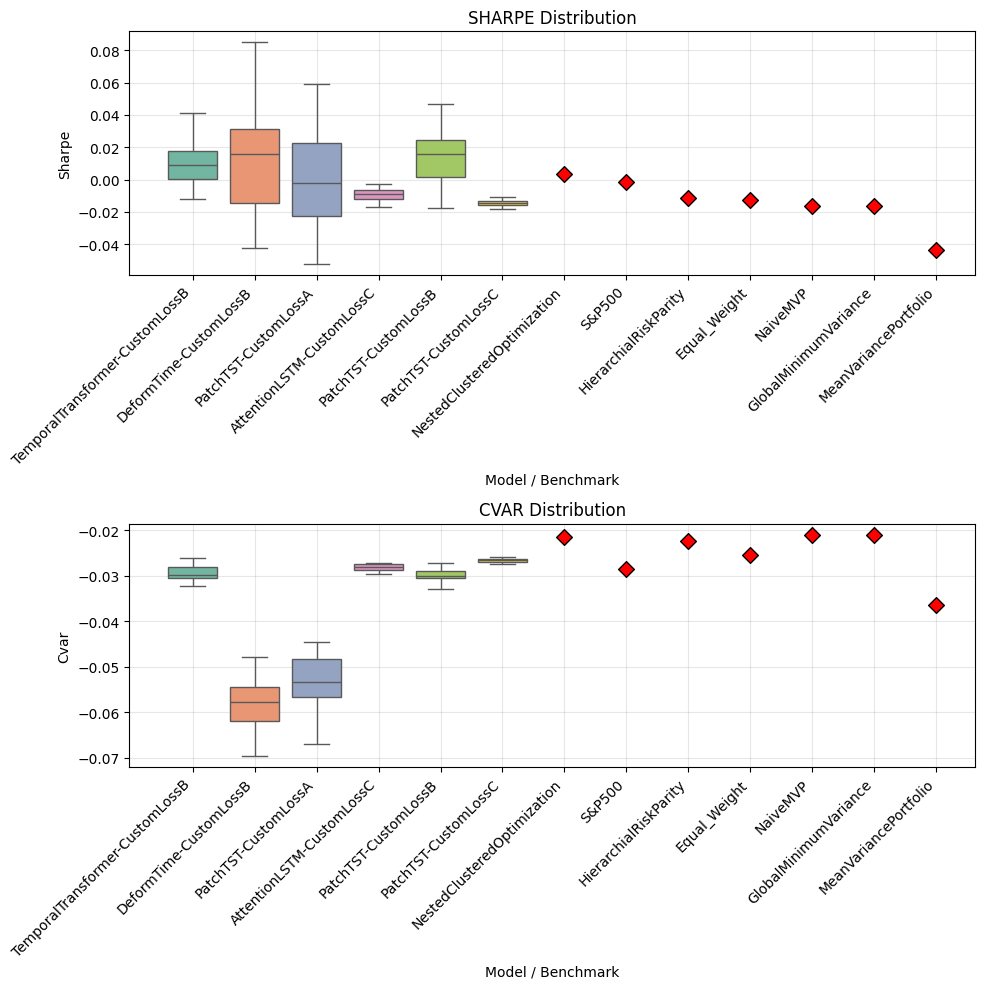

In [24]:
plot_box_models_and_benchs(
    all_seed_perf=all_seed_perf,
    bench_perfs=bench_perfs,
    metrics=metrics_to_use,
    figsize=(10, 5),          # width 10, height 5 per subplot
    benchmark_marker='D'
)

### Statistical Significance
From the correlation of mean of metrics (and even lower confidence bound), use Sharpe, CVaR as our main metrics and we can use Coumpounded returns too. Then we check their normality

In [25]:
from src.visualization.plots import plot_qq_by_model, plot_hist_by_model

Historgrams for Model+Loss Combos, for Selected Metrics


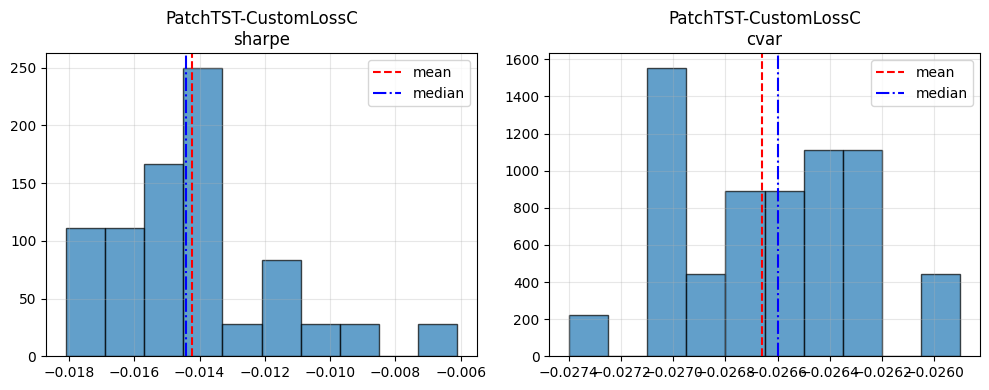

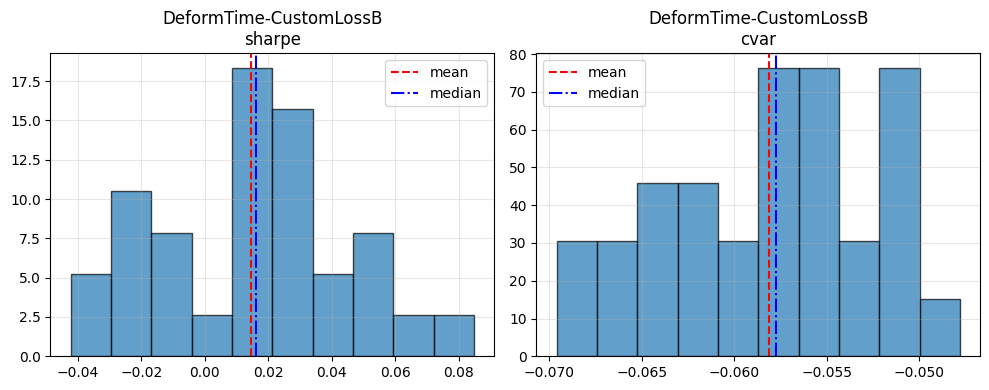

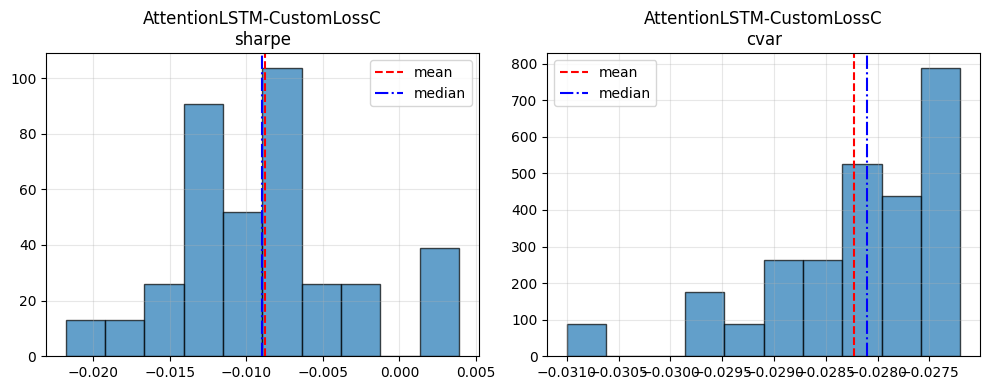

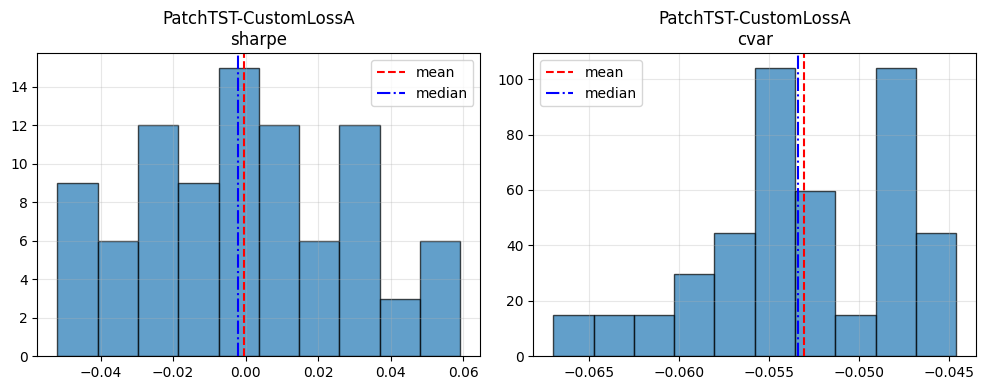

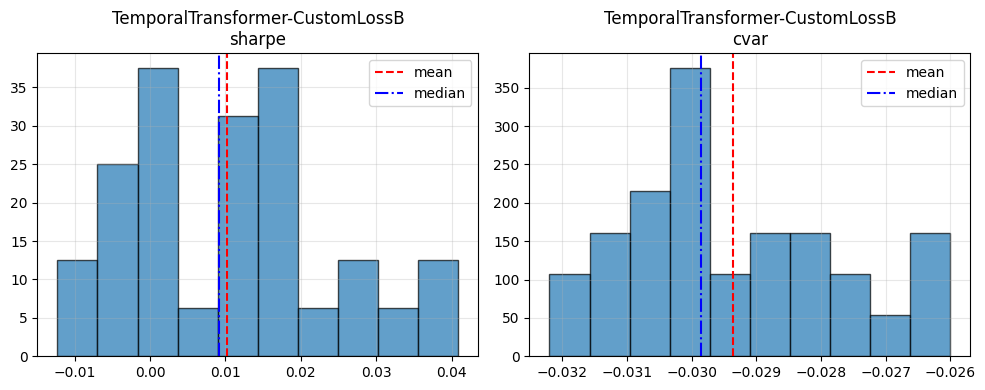

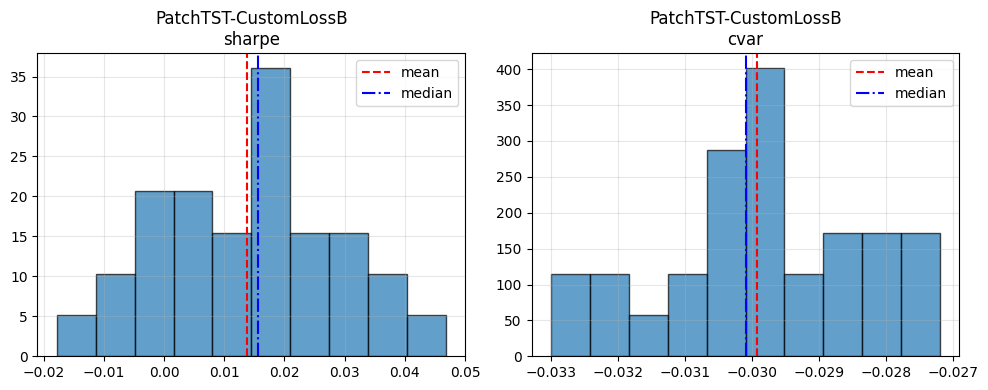

In [26]:
# Historgrams
print('Historgrams for Model+Loss Combos, for Selected Metrics')
plot_hist_by_model(all_seed_perf, nn_models, metrics_to_use, bins=10, n_cols=2)

Q-Q Plots for Model+Loss Combos, for Selected Metrics


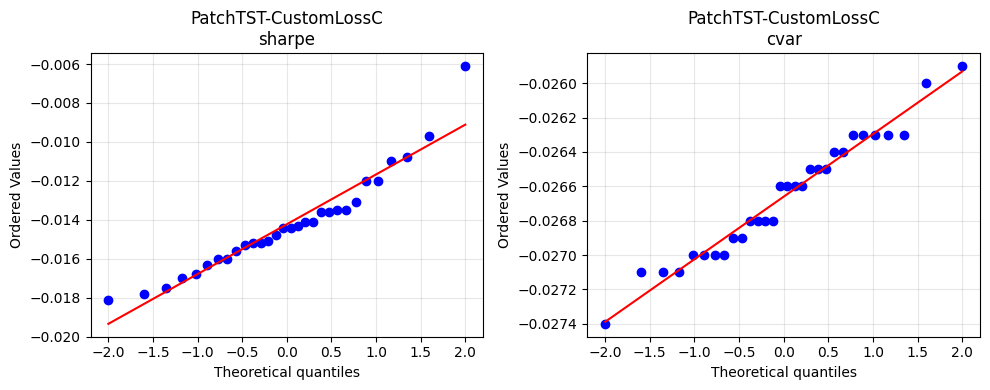

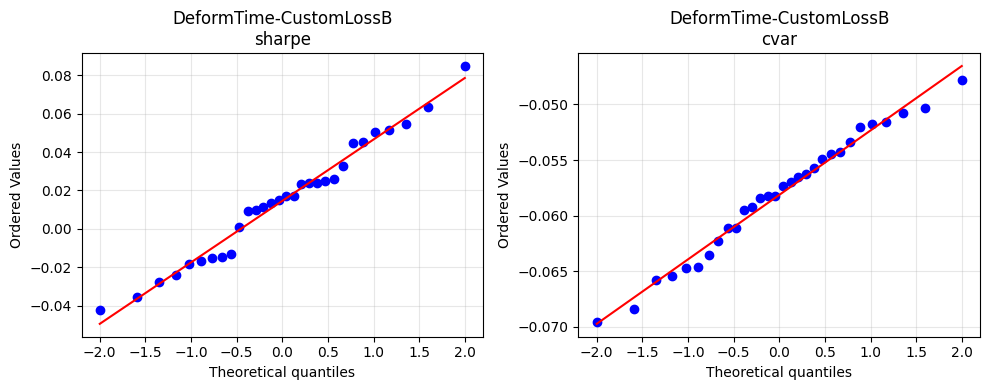

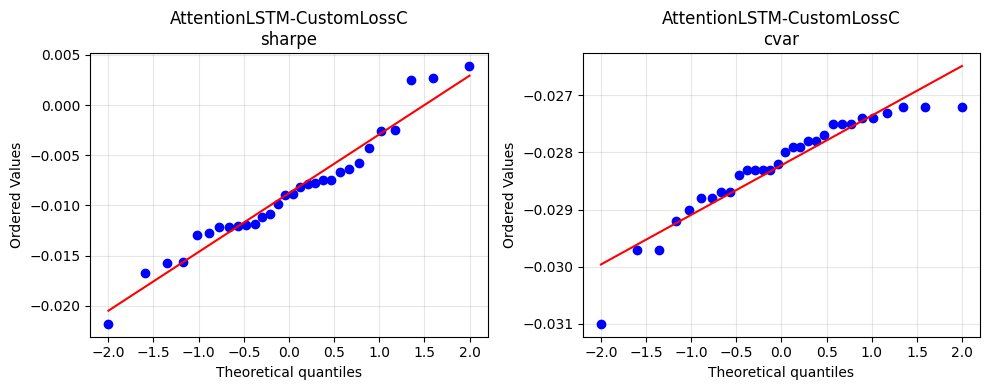

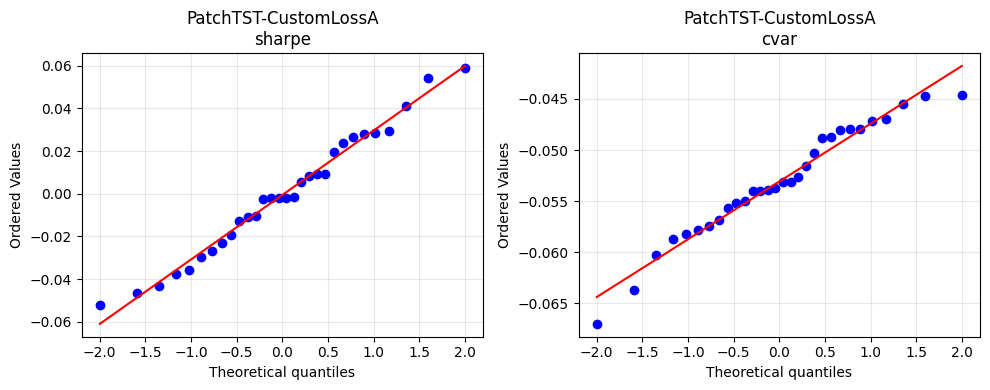

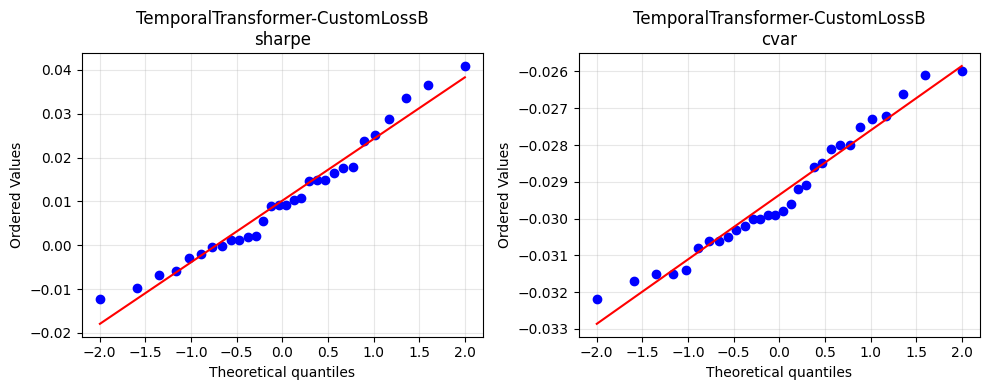

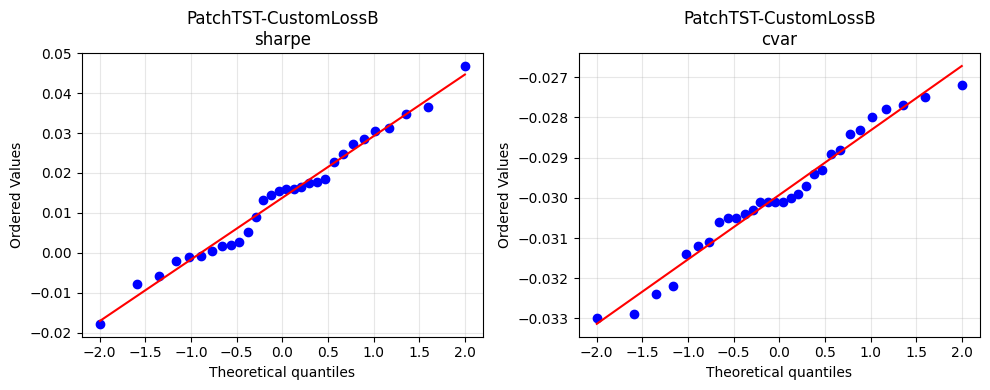

In [27]:
# Q-Q Plots
print('Q-Q Plots for Model+Loss Combos, for Selected Metrics')
plot_qq_by_model(all_seed_perf, nn_models, metrics_to_use, n_cols=2)

##### Shapiro-Wilk Test for normality

In [28]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from scipy import stats

In [29]:
# Function to calculate normality
def test_normality_by_model(
        all_seed_perf: pd.DataFrame,
        nn_models: list[str],
        metrics:list[str]|None=None,
        alpha=0.05
    ):
    """
    Perform Shapiro-Wilk normality test for each metric and each model-loss combination,
    with Bonferroni correction for multiple comparisons.
    
    Args:
        all_seed_perf : pd.DataFrame
            Must contain a column 'model_loss' and metric columns (numerical).
            Each model-loss should have exactly 30 rows (one per seed).
        nn_models : list
            List of model-loss strings to include in the test.
        metrics : list, optional
            List of metric column names to test. If None, all numeric columns except 'model_loss' are used.
        alpha : float, default 0.05
            Significance level before correction.
    
    Returns:
        pd.DataFrame: Columns = 'model_loss', 'metric', 'statistic', 'p_value_raw', 'p_value_corrected',
            'normality_assumed' (True if p_corrected > alpha).
    """
    if metrics is None:
        metrics = all_seed_perf.select_dtypes(include=[np.number]).columns.tolist()
        # remove any non‑metric identifier column named 'seed' if present
        if 'seed' in metrics:
            metrics.remove('seed')
    
    results = []
    total_tests = len(nn_models) * len(metrics)
    
    for model in nn_models:
        sub = all_seed_perf[all_seed_perf.index == model]
        for metric in metrics:
            values = sub[metric].dropna().values
            if len(values) < 3:
                # Not enough samples for Shapiro‑Wilk
                stat, p_raw = np.nan, np.nan
                normal = False
            else:
                stat, p_raw = shapiro(values)
            results.append({
                'model_loss': model,
                'metric': metric,
                'statistic': stat,
                'p_value_raw': p_raw,
                'normality_assumed': False  # placeholder
            })
    
    results_df = pd.DataFrame(results)
    # Apply Bonferroni correction
    results_df['p_value_corrected'] = results_df['p_value_raw'] * total_tests
    results_df['normality_assumed'] = results_df['p_value_corrected'] > alpha
    # Clip corrected p‑values to 1.0
    results_df['p_value_corrected'] = results_df['p_value_corrected'].clip(upper=1.0)
    
    return results_df

normality_table = test_normality_by_model(
    all_seed_perf, nn_models, metrics_to_use
)
normality_table

,model_loss,metric,statistic,p_value_raw,normality_assumed,p_value_corrected
0,PatchTST-CustomLossC,sharpe,0.929702,0.048218,True,0.578613
1,PatchTST-CustomLossC,cvar,0.969225,0.518188,True,1.000000
2,DeformTime-CustomLossB,sharpe,0.977545,0.757206,True,1.000000
3,DeformTime-CustomLossB,cvar,0.978329,0.779602,True,1.000000
4,AttentionLSTM-CustomLossC,sharpe,0.961116,0.330701,True,1.000000
5,AttentionLSTM-CustomLossC,cvar,0.900124,0.008457,True,0.101487
6,PatchTST-CustomLossA,sharpe,0.977961,0.769150,True,1.000000
7,PatchTST-CustomLossA,cvar,0.964047,0.391305,True,1.000000
8,TemporalTransformer-CustomLossB,sharpe,0.964830,0.408891,True,1.000000
9,TemporalTransformer-CustomLossB,cvar,0.959201,0.295497,True,1.000000


#### Hence, we can assume normality!
#### One Sample t-test: All Neural models vs S&P500 -  SHARPE

In [30]:
# Function for 
def one_sample_t_test_vs_benchmark(
    df: pd.DataFrame,
    nn_models: list[str],
    metrics: list[str],
    benchmark_values: dict[str, float],
    alternative: str = 'greater',
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Perform one-sample t-test (one-sided) comparing each model's metric distribution
    to a fixed benchmark value. Applies Bonferroni correction across all tests.

    Args:
        df : pd.DataFrame
            DataFrame with at least columns: `model_col` (model names) and metric columns.
        model_col : str
            Name of the column containing model identifiers (e.g., 'model_loss').
        metrics : list[str]
            List of metric column names to test (e.g., ['sharpe', 'calmar', 'neg_cvar']).
        benchmark_values : dict[str, float]
            Dictionary mapping metric names to the benchmark's single value.
            Keys must match the strings in `metrics`.
        alternative : str, default 'greater'
            Alternative hypothesis for the t-test. Options:
            - 'greater' : model mean > benchmark (higher is better)
            - 'less'    : model mean < benchmark (lower is better)
            - 'two-sided': model mean ≠ benchmark
        alpha : float, default 0.05
            Significance level for the Bonferroni correction (not used in output,
            but included for reference).

    Returns:
        pd.DataFrame:
            Columns: 'model', 'metric', 't_statistic', 'p_value_raw', 'p_value_corrected'
    """
    results = []
    nn_models

    for model in nn_models:
        model_data = df[df.index == model]
        for metric in metrics:
            if metric not in benchmark_values:
                raise KeyError(f"Benchmark value for '{metric}' not found in benchmark_values.")
            values = model_data[metric].dropna().values
            if len(values) == 0:
                continue
            bench_val = benchmark_values[metric]
            t_stat, p_raw = stats.ttest_1samp(values, bench_val, alternative=alternative)
            results.append({
                'model': model,
                'metric': metric,
                't_statistic': t_stat,
                'p_value_raw': p_raw
            })

    results_df = pd.DataFrame(results)
    # Bonferroni correction
    n_tests = len(results_df)
    results_df['p_value_corrected'] = results_df['p_value_raw'] * n_tests
    results_df['p_value_corrected'] = results_df['p_value_corrected'].clip(upper=1.0)

    return results_df

In [32]:
# NN Models vs S&P 500 One Sample t-test
sp500_dict = {k: v for k, v in bench_perfs.loc['S&P500'].to_dict().items() if k in metrics_to_use}
# Run the test
results = one_sample_t_test_vs_benchmark(
    df=all_seed_perf,
    nn_models=nn_models,
    metrics=metrics_to_use,
    benchmark_values=sp500_dict,
    alternative='greater'   # we want model > benchmark
)
print('NN Models vs S&P 500 One Sample t-test')
results.round(4)

NN Models vs S&P 500 One Sample t-test


,model,metric,t_statistic,p_value_raw,p_value_corrected
0,PatchTST-CustomLossC,sharpe,-27.1530,1.0000,1.0000
1,PatchTST-CustomLossC,cvar,26.7829,0.0000,0.0000
2,DeformTime-CustomLossB,sharpe,2.8189,0.0043,0.0516
3,DeformTime-CustomLossB,cvar,-28.9635,1.0000,1.0000
4,AttentionLSTM-CustomLossC,sharpe,-6.9140,1.0000,1.0000
5,AttentionLSTM-CustomLossC,cvar,1.0958,0.1411,1.0000
6,PatchTST-CustomLossA,sharpe,0.1813,0.4287,1.0000
7,PatchTST-CustomLossA,cvar,-24.4381,1.0000,1.0000
8,TemporalTransformer-CustomLossB,sharpe,4.6646,0.0000,0.0004
9,TemporalTransformer-CustomLossB,cvar,-3.0579,0.9976,1.0000


In [36]:
# NN Models vs NCO
sp500_dict = {k: v for k, v in bench_perfs.loc['NestedClusteredOptimization'].to_dict().items() if k in metrics_to_use}
# Run the test
results = one_sample_t_test_vs_benchmark(
    df=all_seed_perf,
    nn_models=nn_models,
    metrics=metrics_to_use,
    benchmark_values=sp500_dict,
    alternative='greater'   # we want model > benchmark
)
print('NN Models vs NCO One Sample t-test')
results

NN Models vs NCO One Sample t-test


,model,metric,t_statistic,p_value_raw,p_value_corrected
0,PatchTST-CustomLossC,sharpe,-37.604678,1.000000,1.000000
1,PatchTST-CustomLossC,cvar,-79.425140,1.000000,1.000000
2,DeformTime-CustomLossB,sharpe,1.956724,0.030035,0.360420
3,DeformTime-CustomLossB,cvar,-35.683383,1.000000,1.000000
4,AttentionLSTM-CustomLossC,sharpe,-11.569845,1.000000,1.000000
5,AttentionLSTM-CustomLossC,cvar,-41.702182,1.000000,1.000000
6,PatchTST-CustomLossA,sharpe,-0.734738,0.765800,1.000000
7,PatchTST-CustomLossA,cvar,-31.270480,1.000000,1.000000
8,TemporalTransformer-CustomLossB,sharpe,2.711021,0.005576,0.066912
9,TemporalTransformer-CustomLossB,cvar,-25.112866,1.000000,1.000000


#### Paired t-test: AttentionLSTM-customloss11 vs all the others

In [37]:
best = 'AttentionLSTM-CustomLossB'
other_models = [m for m in all_seed_perf.index.unique() if m != best]

# Prepare a list to store results
paired_results = []

for other in other_models:
    # Get the 30 Sharpe values for each model (aligned by seed)
    best_vals = all_seed_perf[all_seed_perf.index == best]['sharpe'].values
    other_vals = all_seed_perf[all_seed_perf.index == other]['sharpe'].values
    # One‑sided: best > other
    t_stat, p_raw = stats.ttest_rel(best_vals, other_vals, alternative='greater')
    paired_results.append({
        'model': other,
        't_statistic': t_stat,
        'p_value_raw': p_raw
    })

paired_df = pd.DataFrame(paired_results)
# Bonferroni correction (5 pairwise tests)
n_tests = len(paired_df)
paired_df['p_value_corrected'] = paired_df['p_value_raw'] * n_tests
paired_df['p_value_corrected'] = paired_df['p_value_corrected'].clip(upper=1.0)
paired_df.round(4)

ValueError: Array shapes are incompatible for broadcasting.

#### From the analysis and statistical test we can we see AttentionLSTM is best and DeformTime comes second, both with custom-Loss-11

Mean of AttentionLSTM-custom_loss_11 annd its 95% confidence interval

In [38]:
def mean_ci_for_model(
        modl: str, metric: str, avg_perf_metrics: pd.DataFrame, 
        std_perf_metrics: pd.DataFrame, n: int
):
    mean = avg_perf_metrics.loc[modl][metric]
    std = std_perf_metrics.loc[modl][metric]
    se = std / np.sqrt(n)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    print(f"Mean {metric.upper()} = {mean:.5f}, 95% CI = [{ci[0]:.5f}, {ci[1]:.5f}]")

mean_ci_for_model(best, 'sharpe', avg_perf_metrics, std_perf_metrics, n_seeds)
mean_ci_for_model(best, 'cvar', avg_perf_metrics, std_perf_metrics, n_seeds)

KeyError: 'AttentionLSTM-CustomLossB'

#### Lower Confidence Bound Metrics Pareto Frontier Analysis

Pareto Frontier for all metrics

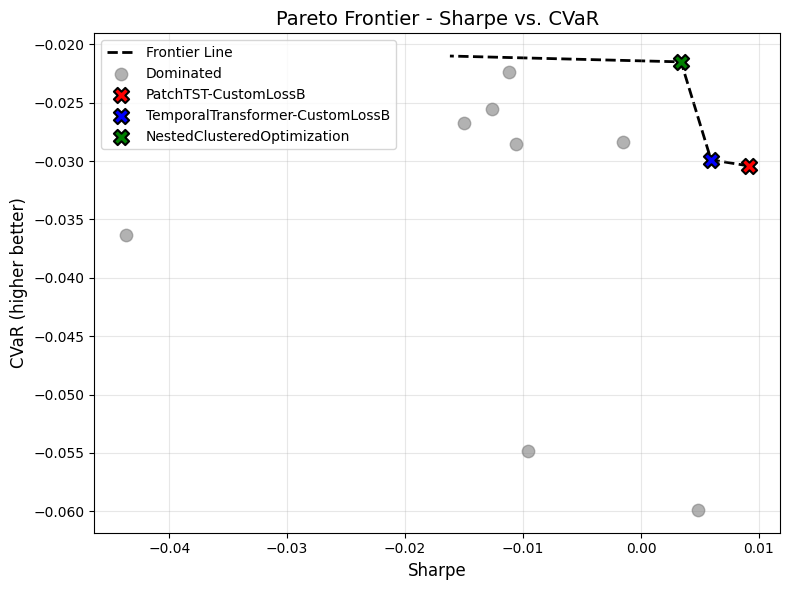

In [39]:
temp_perf = lower_bound_df.copy()

temp_perf['dominated'] = pareto_dominance(temp_perf, ['sharpe', 'cvar'])

frontier_2d = temp_perf[~temp_perf['dominated']]

# fig = plot_2d_pareto(
#     df=temp_perf,
#     x_col='sharpe',
#     y_col='cvar',
#     dominated_col='dominated',
#     title='2D Pareto Frontier - Sharpe vs CVaR (Test Set)',
#     xlabel='Sharpe',
#     ylabel='CVaR (higher better)'
# )
# plt.show()
# frontier_sorted = frontier_2d.sort_values('sharpe', ascending=False)
# frontier_sorted


plot_2d_pareto_diff_colrs(
    df=temp_perf,
    x_col='sharpe',
    y_col='cvar',
    dominated_col='dominated',
    title='Pareto Frontier - Sharpe vs. CVaR',
    xlabel='Sharpe',
    ylabel='CVaR (higher better)',
    colormap=['red','blue','green'],
    line_color='black'
)

plt.show()

#### Daily returns for AttentionLSTM, NCO, S&P500 and Equal Weight Portfolio

In [40]:
from src.visualization.plots import plot_wind_comparison_str_dates

In [41]:
# Get the window dates (These dates are common across all models/methods)
dates_list = list(bench_rets['NestedClusteredOptimization'].keys())
dates_list

['2022-01-03_2022-03-29',
 '2022-03-30_2022-06-24',
 '2022-06-27_2022-09-20',
 '2022-09-21_2022-12-14',
 '2022-12-15_2023-03-14',
 '2023-03-15_2023-06-08',
 '2023-06-09_2023-09-05',
 '2023-09-06_2023-11-29']

#### Selecting Seed
We select a single seed for further analysis. The selected seed gives the sharpe closest to the median sharpe of AttentionLSTM-CustomLossB

In [59]:
best = 'TemporalTransformer-CustomLossB'

seed_sharpe_list = []
for seed in nn_seed_rets_no_dates.keys():
    
    evaluator = Evaluator(
        eval_returns=None,
        ba_eval=None,
        all_daily_returns={best: nn_seed_rets_no_dates[seed][best]},
        metrics_lib=MetricLibrary.items()
    )
    seed_sharpe = float(evaluator.calc_pf_performances()['sharpe'][best])
    seed_sharpe_list.append((seed, seed_sharpe))

sharpe_values = np.array([sharpe for _, sharpe in seed_sharpe_list])
median_sharpe = np.median(sharpe_values)

# Find index of the value closest to the median
idx = np.argmin(np.abs(sharpe_values - median_sharpe))
selected_seed = seed_sharpe_list[idx][0]

print(f'Closest seed to median sharpe: {selected_seed}')
# seed_sharpe_list

Closest seed to median sharpe: 313233


In [60]:
# Get returns for required models/methods
# best = AttentionLSTM-CustomLossB
top_benches = ['NestedClusteredOptimization', 'S&P500']
rets_for_plot = {}
rets_for_plot.update({best: nn_seed_rets_no_dates[selected_seed][best]})

for top_bench in top_benches:
    rets_for_plot.update({top_bench: bench_rets_no_dates[top_bench]})

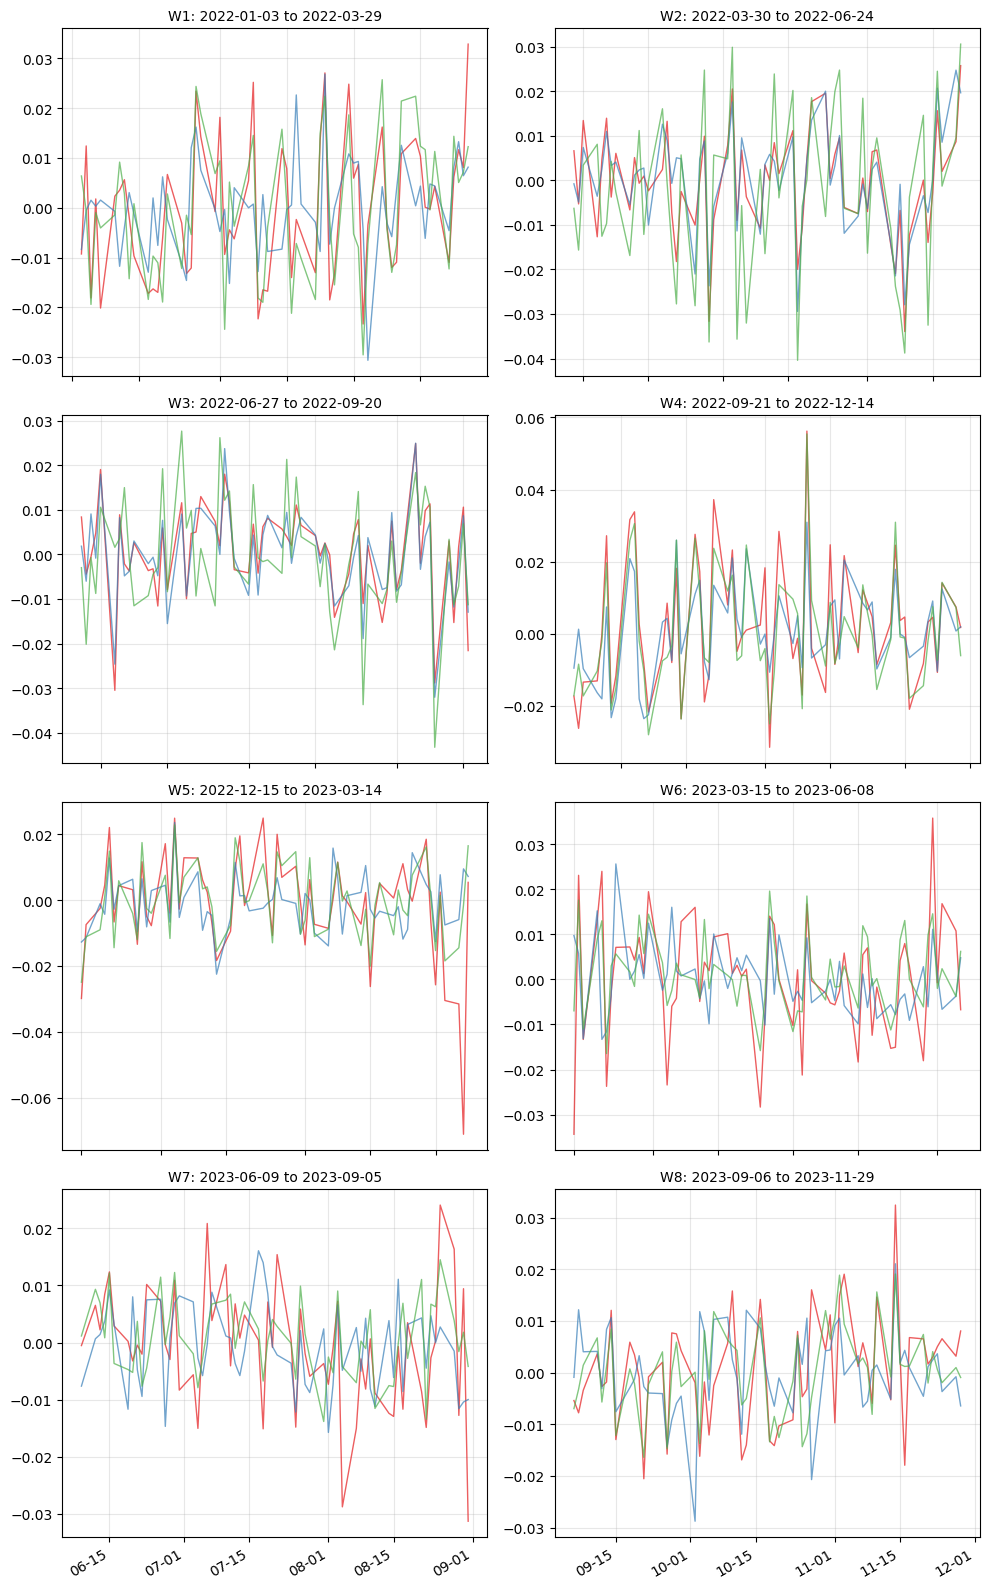

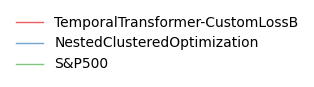

In [61]:
plot_wind_comparison_str_dates(rets_for_plot, dates_list, 2, plot=True)

In [62]:
# Combine all windows

combined_returns = {
    model: np.concatenate(arr) for model, arr in rets_for_plot.items()
}

In [63]:
from src.visualization.plots import plot_concatenated_returns

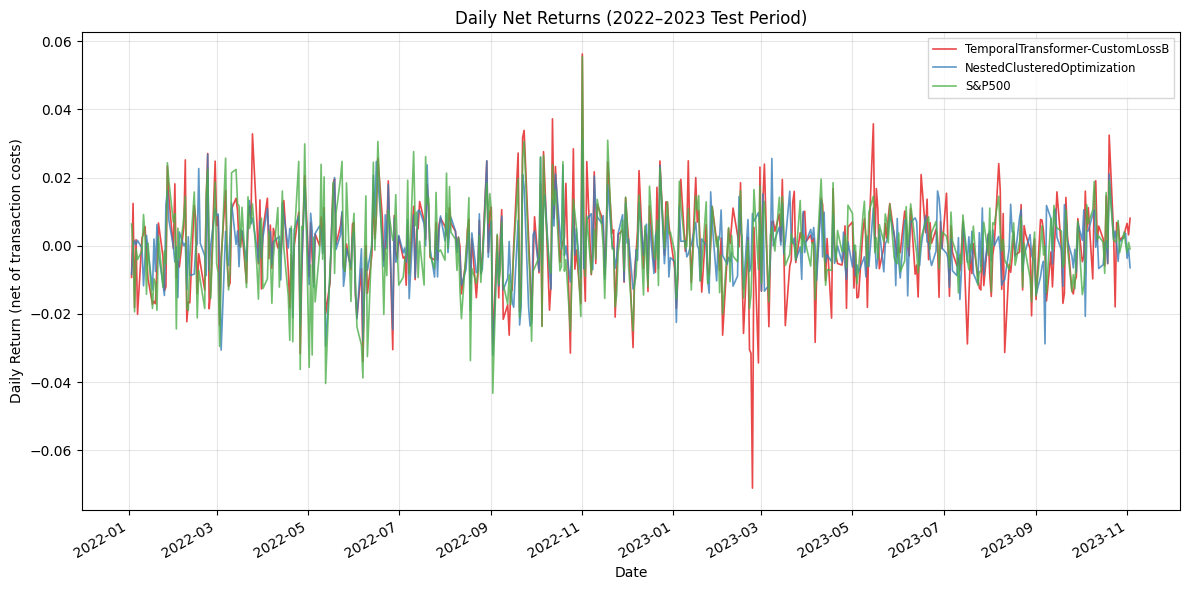

In [64]:
plot_concatenated_returns(
    combined_returns, dates_list,
    plot=True
)

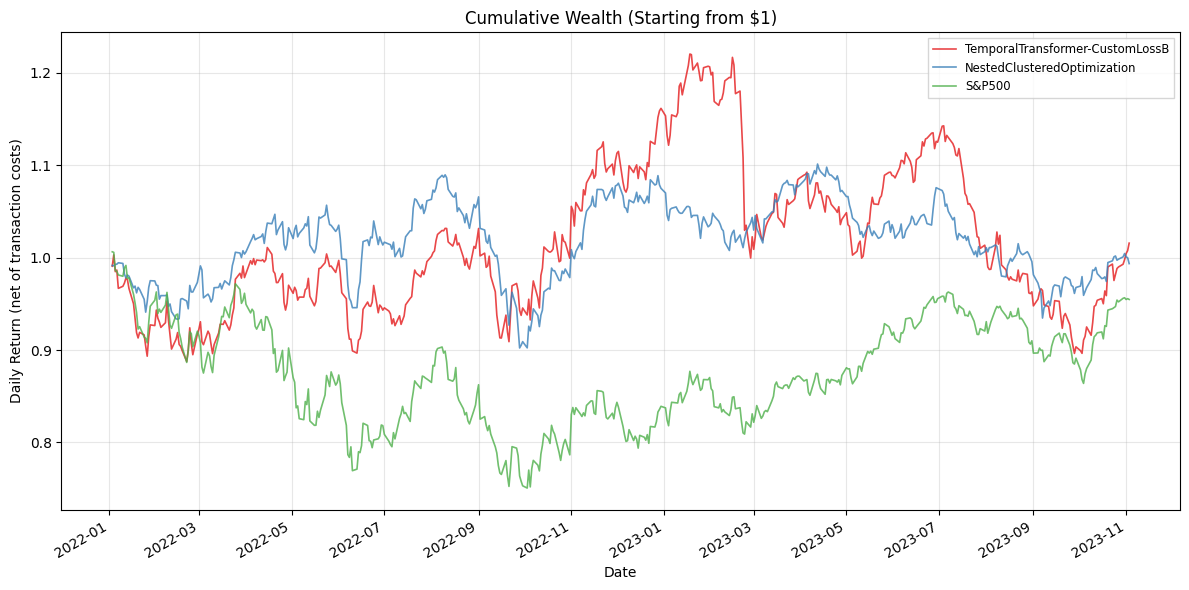

In [65]:
def cumulative_returns(daily_returns: np.ndarray):
    """Convert daily returns to cumulative wealth (starting at 1)."""
    return (1 + daily_returns).cumprod()

all_cum_returns = {model: cumulative_returns(arr) for model, arr in combined_returns.items()}

plot_concatenated_returns(
    all_cum_returns, dates_list,
    plot=True,
    title='Cumulative Wealth (Starting from $1)'
)

In [68]:
evaluator = Evaluator(
    eval_returns=None,
    ba_eval=None,
    all_daily_returns=rets_for_plot,
    metrics_lib=MetricLibrary.items()
)

per_wind_sharpe = evaluator.calc_metric_performance(MetricLibrary.get('sharpe'), mean=False)
per_wind_sharpe['dates'] = dates_list
print('Per Window Sharpe Ratios:')
per_wind_sharpe

Per Window Sharpe Ratios:


,TemporalTransformer-CustomLossB,NestedClusteredOptimization,S&P500,dates
0,-0.0223,0.0151,-0.0287,2022-01-03_2022-03-29
1,-0.0420,0.0223,-0.1479,2022-03-30_2022-06-24
2,0.0651,-0.0052,-0.0119,2022-06-27_2022-09-20
3,0.1312,0.0946,0.0447,2022-09-21_2022-12-14
4,-0.0705,-0.0958,-0.0238,2022-12-15_2023-03-14
5,0.0345,0.0061,0.1881,2023-03-15_2023-06-08
6,-0.0974,-0.1064,0.1202,2023-06-09_2023-09-05
7,0.0432,0.0316,0.0283,2023-09-06_2023-11-29


In [69]:
per_wind_mdd = evaluator.calc_metric_performance(MetricLibrary.get('max_drawdown'), mean=False)
per_wind_mdd['dates'] = dates_list
print('Per Window Max Drawdown:')
per_wind_mdd

Per Window Max Drawdown:


,TemporalTransformer-CustomLossB,NestedClusteredOptimization,S&P500,dates
0,-0.1150,-0.0614,-0.1305,2022-01-03_2022-03-29
1,-0.1131,-0.1050,-0.2033,2022-03-30_2022-06-24
2,-0.0501,-0.0721,-0.1044,2022-06-27_2022-09-20
3,-0.0562,-0.1002,-0.0564,2022-09-21_2022-12-14
4,-0.1564,-0.0745,-0.0775,2022-12-15_2023-03-14
5,-0.0852,-0.0721,-0.0260,2023-03-15_2023-06-08
6,-0.1361,-0.0889,-0.0478,2023-06-09_2023-09-05
7,-0.0917,-0.0793,-0.0861,2023-09-06_2023-11-29


In [70]:
per_wind_comp_ret = evaluator.calc_metric_performance(MetricLibrary.get('compunded_return'), mean=False)
per_wind_comp_ret['dates'] = dates_list
print('Per Window Compounded Return:')
per_wind_comp_ret

Per Window Compounded Return:


,TemporalTransformer-CustomLossB,NestedClusteredOptimization,S&P500,dates
0,-0.0234,0.0059,-0.0282,2022-01-03_2022-03-29
1,-0.0333,0.0115,-0.1554,2022-03-30_2022-06-24
2,0.0381,-0.0062,-0.0143,2022-06-27_2022-09-20
3,0.1378,0.0688,0.0362,2022-09-21_2022-12-14
4,-0.0717,-0.0489,-0.0190,2022-12-15_2023-03-14
5,0.0223,0.0010,0.0956,2023-03-15_2023-06-08
6,-0.0624,-0.0473,0.0473,2023-06-09_2023-09-05
7,0.0238,0.0137,0.0120,2023-09-06_2023-11-29
